✅ Đã load dữ liệu từ file cleaned.
🚀 Số dòng dữ liệu đưa vào clustering: 30,341
🛠️ Các feature sử dụng: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed']

🔍 Đang chạy Elbow Method...


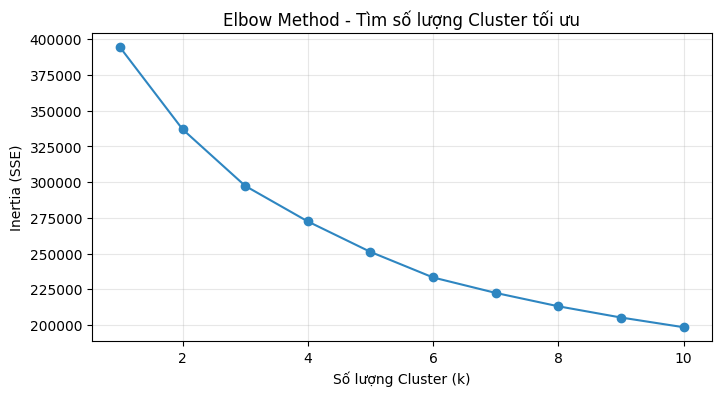

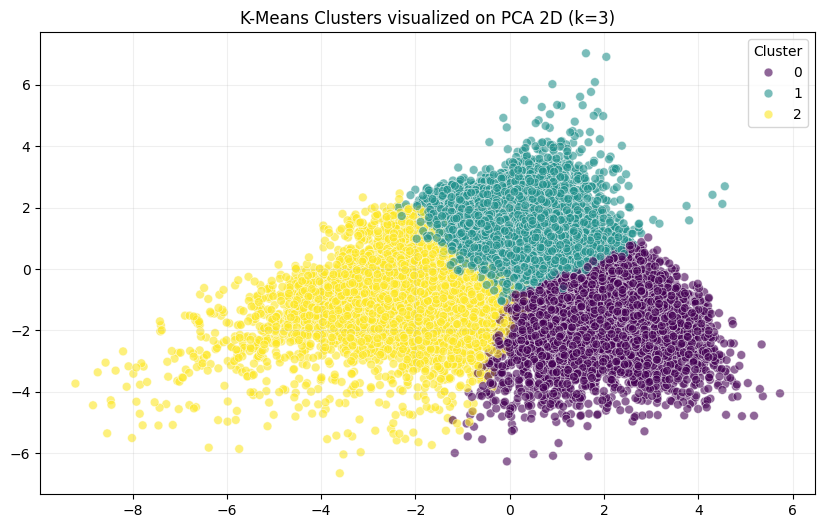


📊 Đang tính toán Silhouette Profile (Sampling 3000 mẫu)...
✅ Silhouette Score trung bình: 0.154


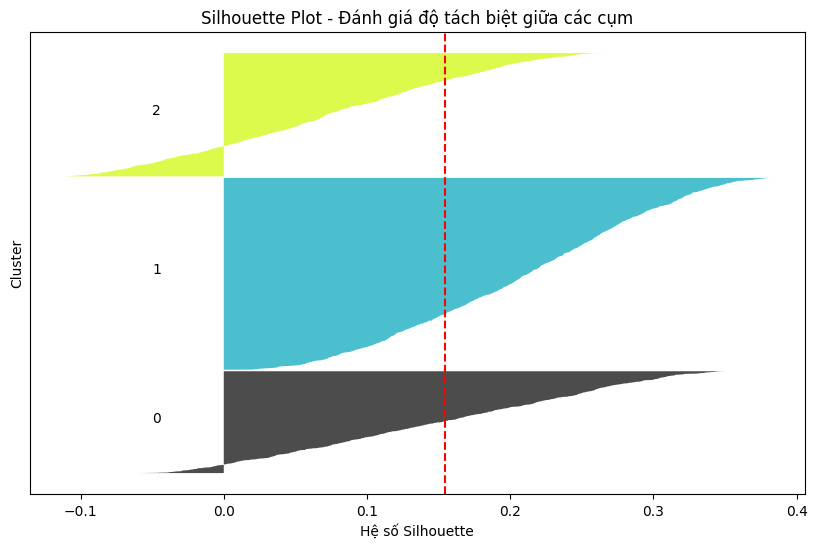


============================== KẾT QUẢ PHÂN CỤM ==============================

📍 GIÁ TRỊ TRUNG BÌNH TẠI TÂM CỤM:
       co    no2      o3    pm10   pm25    so2  clouds  precipitation  pressure  relative_humidity  temperature  uv_index  wind_speed
0  189.55  13.49  112.73   54.48  41.09  73.97   57.23           0.11   1007.43              61.03        29.81      3.60        2.04
1  460.91  24.48   41.63   46.28  34.07  47.15   71.87           0.41   1006.74              86.00        26.23      0.64        1.77
2  360.76  43.35   42.22  117.60  84.78  79.86   79.86           0.08   1017.46              76.37        19.04      0.72        1.59

📍 AQI TRUNG BÌNH THEO CỤM (Thứ tự ô nhiễm giảm dần):
cluster
2    172.79
0    113.77
1     98.11
Name: aqi, dtype: float64

📍 PHÂN BỐ CÁC CỤM THEO MÙA:
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            2258  1920  1925   636
1            5055  3119  4885  1526
2              31  1514  2025  5447

✅ Hoàn tất phân

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# ==========================================
# 1. LOAD DỮ LIỆU
# ==========================================
try:
    df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv', low_memory=False)
    print("✅ Đã load dữ liệu từ file cleaned.")
except Exception as e:
    print(f"⚠️ Error reading cleaned file: {e}")
    files = ['../data_raw/2022.csv', '../data_raw/2023.csv', '../data_raw/2024.csv', '../data_raw/2025.csv']
    df_list = [pd.read_csv(f, low_memory=False) for f in files if os.path.exists(f)]
    df = pd.concat(df_list, ignore_index=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}

# ==========================================
# 2. CHUẨN BỊ FEATURE (BỎ DROPNA THEO Ý )
# ==========================================
feature_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
                'precipitation', 'pressure', 'relative_humidity', 
                'temperature', 'uv_index', 'wind_speed']

available_features = [col for col in feature_cols if col in df.columns]

# Dùng copy() để giữ nguyên Index gốc, tránh lệch dữ liệu khi gán cluster
X = df[available_features].copy()

print(f"🚀 Số dòng dữ liệu đưa vào clustering: {len(X):,}")
print(f"🛠️ Các feature sử dụng: {available_features}\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. ELBOW METHOD (TÌM K)
# ==========================================
print("🔍 Đang chạy Elbow Method...")
inertia = []
ks = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(ks, inertia, marker='o', color='#2E86C1')
plt.title('Elbow Method - Tìm số lượng Cluster tối ưu')
plt.xlabel('Số lượng Cluster (k)')
plt.ylabel('Inertia (SSE)')
plt.grid(alpha=0.3)
plt.show()

# ==========================================
# 4. K-MEANS CLUSTERING (K=3)
# ==========================================
k_opt = 3
km = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

# PCA 2D để quan sát các cụm
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis', s=40, alpha=0.6)
plt.title(f'K-Means Clusters visualized on PCA 2D (k={k_opt})')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
plt.show()

# ==========================================
# 5. ĐÁNH GIÁ VỚI SILHOUETTE SCORE
# ==========================================
print("\n📊 Đang tính toán Silhouette Profile (Sampling 3000 mẫu)...")
sample_size = min(3000, len(X_scaled))
indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]
labels_sample = labels[indices]

sil_avg = silhouette_score(X_sample, labels_sample)
sample_sil_values = silhouette_samples(X_sample, labels_sample)

print(f"✅ Silhouette Score trung bình: {sil_avg:.3f}")

# Vẽ Silhouette Plot
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(k_opt):
    ith_cluster_sil_values = sample_sil_values[labels_sample == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = cm.nipy_spectral(float(i) / k_opt)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, facecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=sil_avg, color="red", linestyle="--")
plt.title("Silhouette Plot - Đánh giá độ tách biệt giữa các cụm")
plt.xlabel("Hệ số Silhouette")
plt.ylabel("Cluster")
plt.yticks([])
plt.show()

# ==========================================
# 6. BÁO CÁO KẾT QUẢ & ĐẶC TRƯNG
# ==========================================
clustered_df = df.loc[X.index].copy()
clustered_df['cluster'] = labels

# Tâm cụm ở đơn vị gốc
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=available_features
)

print("\n" + "="*30 + " KẾT QUẢ PHÂN CỤM " + "="*30)
print("\n📍 GIÁ TRỊ TRUNG BÌNH TẠI TÂM CỤM:")
print(cluster_centers.round(2))

if 'aqi' in clustered_df.columns:
    print("\n📍 AQI TRUNG BÌNH THEO CỤM (Thứ tự ô nhiễm giảm dần):")
    aqi_rank = clustered_df.groupby('cluster')['aqi'].mean().sort_values(ascending=False)
    print(aqi_rank.round(2))

# Thêm thông tin thời gian để phân tích sâu
if 'date' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['date'].dt.hour
    if 'season' in clustered_df.columns:
        clustered_df['season_name'] = clustered_df['season'].map(SEASON_MAP)
        print("\n📍 PHÂN BỐ CÁC CỤM THEO MÙA:")
        print(clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0))

print("\n✅ Hoàn tất phân cụm dữ liệu.")

In [19]:
import pandas as pd

# Show full table output instead of truncated notebook display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season (full table):')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour (full table):')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours.to_string())

if 'aqi' in clustered_df.columns:
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2).to_string())


Cluster distribution by season (full table):
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            2258  1920  1925   636
1            5055  3119  4885  1526
2              31  1514  2025  5447

Cluster distribution by hour (full table):
hour         0
cluster       
0         6739
1        14585
2         9017

Hour with most members in each cluster:
cluster
0    0
1    0
2    0

Clusters ranked by mean AQI:
cluster
2    172.79
0    113.77
1     98.11
